The purpose of this Jupyter Notebook is to easily visualize the distribution of the Regress LM datasets we are experimenting with.

In [1]:
# Libary imports
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from ast import literal_eval
import pandas as pd
import numpy as np

### Code Regression Dataset Vizzes

In [2]:
# Load dataset
code_regression_dataset = load_dataset("akhauriyash/Code-Regression", split="train")

In [3]:
# Select columns and convert to Pandas DF
code_regression_dataset = code_regression_dataset.select_columns(["target", "space", "metadata"]) # filter by only these 3 columns since dataset is 7+ million rows
code_df = code_regression_dataset.to_pandas()

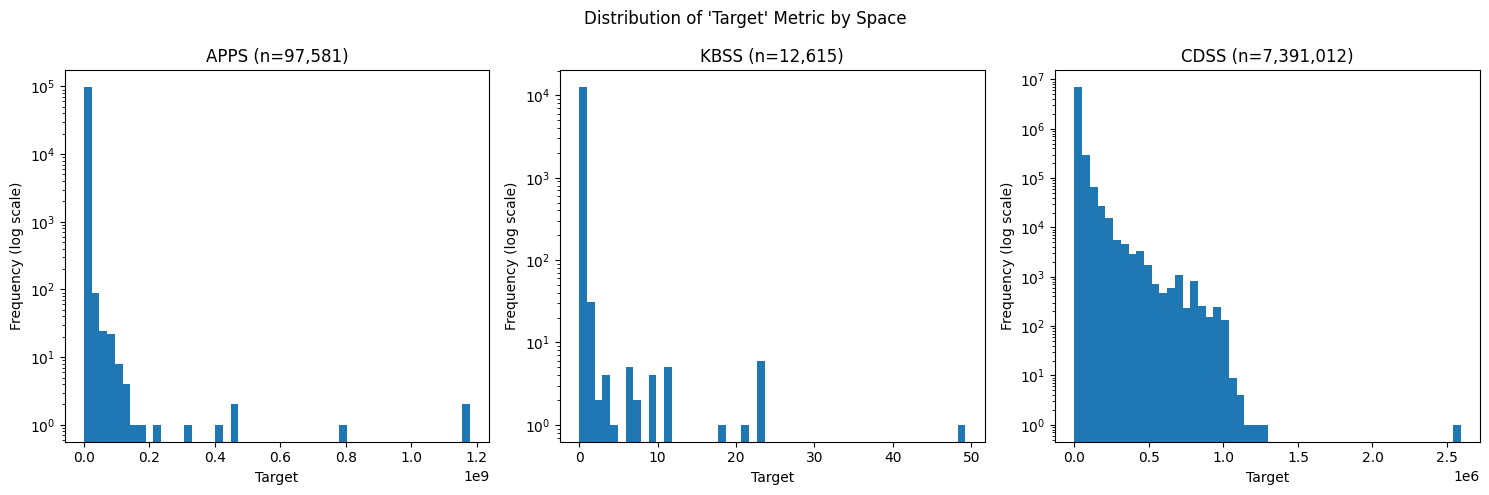

In [4]:
# Define dataset splits (by spaces)
spaces = ["APPS", "KBSS", "CDSS"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle("Distribution of 'Target' Metric by Space")

for ax, space in zip(axes, spaces):
    # Filter the target values by space and drop na values
    subset = code_df[code_df["space"] == space]["target"].dropna()
    
    # Plot histogram
    ax.hist(subset, bins=50)
    
    # Format histogram
    ax.set_title(f"{space} (n={len(subset):,})") # Add space label
    ax.set_xlabel("Target")
    ax.set_ylabel("Frequency (log scale)")
    ax.set_yscale('log') # Use log scale to visualize better

plt.tight_layout()

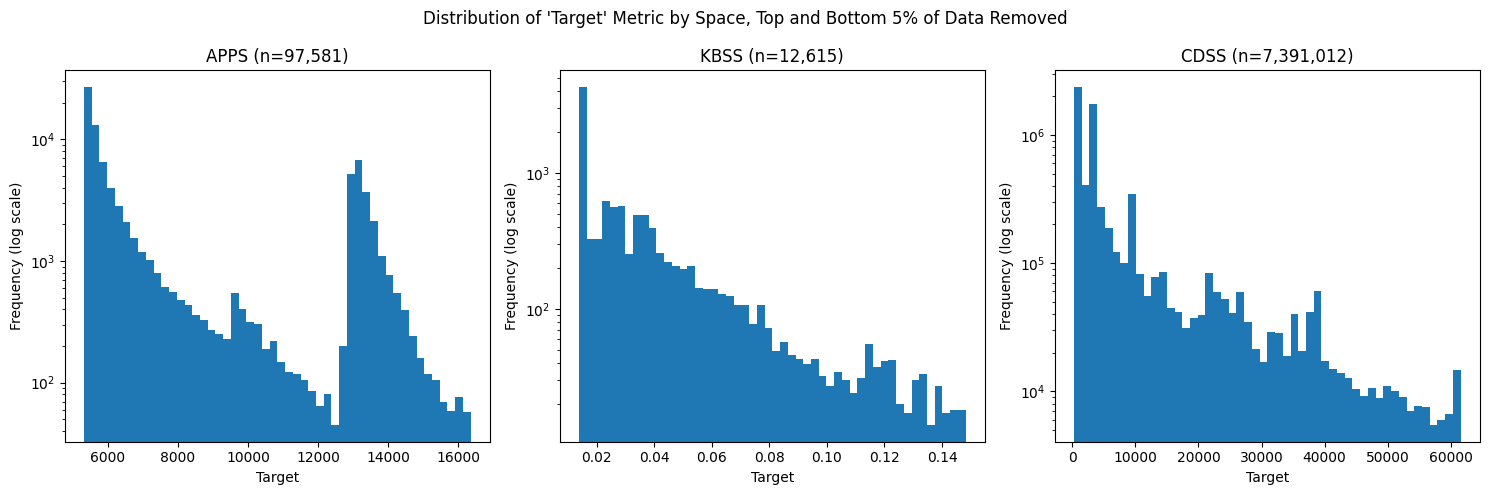

In [5]:
# Plot histogram distributions of each space but clip the top and bottom 5% of extreme outliers

# Define dataset splits (by spaces)
spaces = ["APPS", "KBSS", "CDSS"]

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=False)
fig.suptitle("Distribution of 'Target' Metric by Space, Top and Bottom 5% of Data Removed")

for ax, space in zip(axes, spaces):
    # Filter the target values by space and drop na values
    subset = code_df[code_df["space"] == space]["target"].dropna()
    
    # Plot histogram
    ax.hist(subset, bins=50, range=(subset.quantile(0.05),subset.quantile(0.95)))
    
    # Format histogram
    ax.set_title(f"{space} (n={len(subset):,})")
    ax.set_xlabel("Target")
    ax.set_ylabel("Frequency (log scale)")
    ax.set_yscale('log') # Use log scale to visualize better

plt.tight_layout()

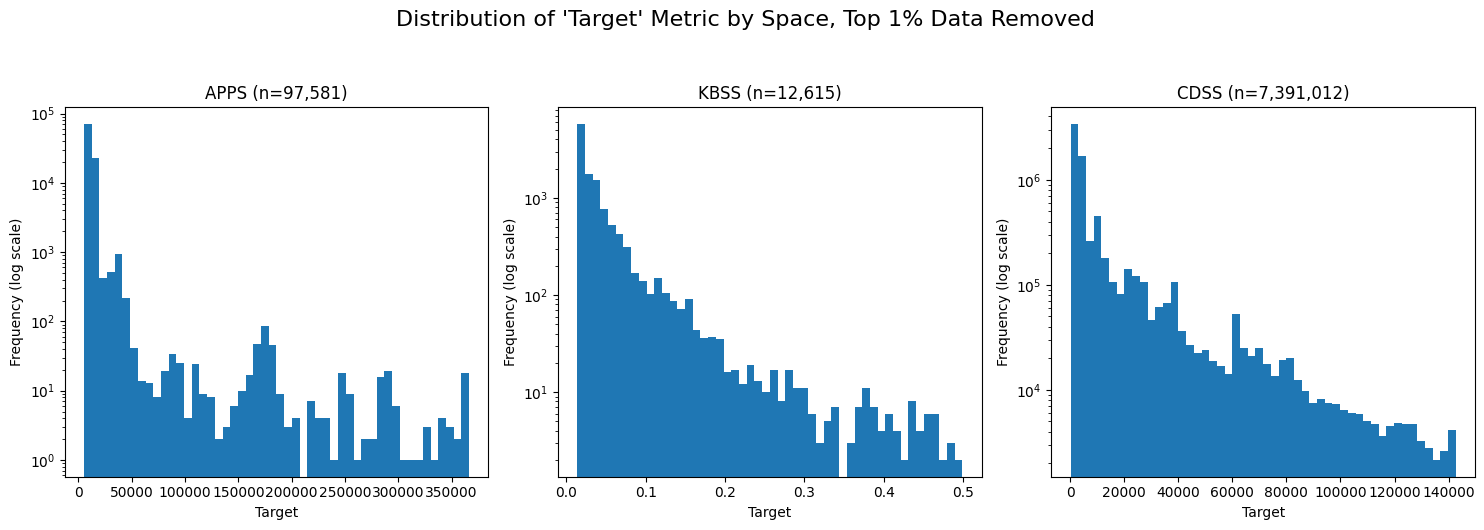

In [ ]:
# Plot histogram distributions of each space but clip the top and bottom 1% of extreme outlier

# Define dataset splits (by spaces)
spaces = ["APPS", "KBSS", "CDSS"]

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=False)
fig.suptitle("Distribution of 'Target' Metric by Space, Top 1% Data Removed")

for ax, space in zip(axes, spaces):
     # Filter the target values by space and drop na values
    subset = code_df[code_df["space"] == space]["target"].dropna()
    
    # Plot histogram
    ax.hist(subset, bins=50, range=(subset.min(),subset.quantile(0.99)))
    
    # Format histogram
    ax.set_title(f"{space} (n={len(subset):,})")
    ax.set_xlabel("Target")
    ax.set_ylabel("Frequency (log scale)")
    ax.set_yscale('log') # Use log scale to visualize better

plt.tight_layout()

### Exploration of Spurious Correlations in the Code Regression Dataset

In [ ]:
# Dataset can be accessed via 'code_df' loaded earlier, preview here for a sanity check
code_df.head()

,target,space,metadata
0,6036.0,APPS,"{'question_id': '0291', 'solution_index': '131..."
1,5354.0,APPS,"{'question_id': '4146', 'solution_index': '77'..."
2,7244.0,APPS,"{'question_id': '4141', 'solution_index': '8',..."
3,6591.0,APPS,"{'question_id': '4510', 'solution_index': '8',..."
4,13235.0,APPS,"{'question_id': '1284', 'solution_index': '17'..."


First we need to preprocess the data.

In [6]:
# Create new CDSS DF, copy of original "code_df" dataframe, but filtered only for CDSS space data
cdss_df = code_df[code_df['space'] == 'CDSS'].copy()
# Filter out top 1% of data based on "target" metric
q_99 = cdss_df['target'].quantile(0.99)
filtered_cdss = cdss_df[cdss_df['target'] <= q_99].copy()

# Convert string to dicts for the "metadata" field to separate out each property
dicts = [literal_eval(x) for x in filtered_cdss['metadata']]

# Use json_normalize to flatten the dicts
metadata_df = pd.json_normalize(dicts).set_index(filtered_cdss.index)

# Join flattened metadata df columns back into filtered CDSS df
filtered_cdss = pd.concat([filtered_cdss.drop('metadata', axis=1), metadata_df], axis=1)

In [8]:
# Sanity check
filtered_cdss.head()

,target,space,s_id,p_id,u_id,date,language,original_language,filename_ext,status,cpu_time,memory,code_size
111547,256.0,CDSS,s783831872,p03250,u426572476,1563060262,C++,C++14 (GCC 5.4.1),cpp,Accepted,1,256,332
111548,2940.0,CDSS,s060487191,p03288,u349444371,1588189955,Python,Python (3.4.3),py,Accepted,17,2940,95
111549,3636.0,CDSS,s193613386,p02694,u445619807,1588468532,C++,C++ (GCC 9.2.1),cpp,Accepted,5,3636,230
111550,384.0,CDSS,s644057497,p02949,u166378830,1590420339,C++,C++14 (GCC 5.4.1),cpp,Accepted,73,384,971
111551,896.0,CDSS,s046026246,p02954,u561765782,1564967689,C++,C++14 (GCC 5.4.1),cpp,Accepted,11,896,766


Now let's plot and see the distribution of the 'target' metric (`memory_bytes`) versus different fields in the metadata. For the CDSS space split, `memory_bytes` represents the max amount of memory that running the `input` string takes in the system.

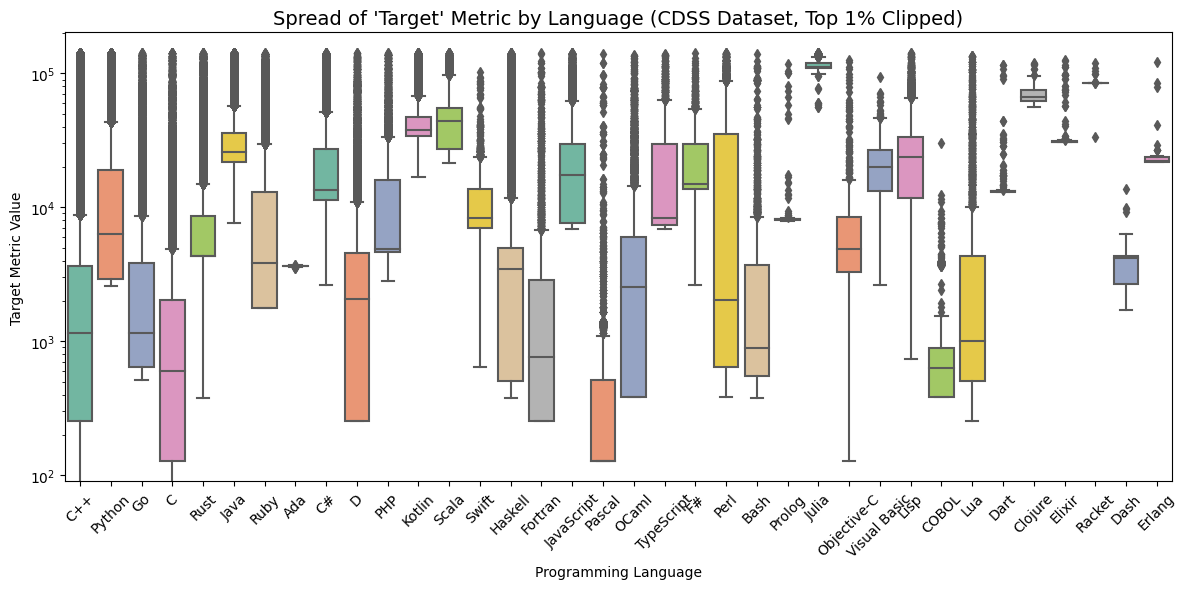

In [11]:
# Init plot
plt.figure(figsize=(12, 6))

# Plot a boxplot to view overall distributions by language
sns.boxplot(
    data=filtered_cdss, 
    x='language', 
    y='target', 
    palette='Set2',
    showfliers=True # show outliers
)

# Format boxplot
plt.title("Spread of 'Target' Metric by Language (CDSS Dataset, Top 1% Clipped)", fontsize=14)
plt.ylabel("Target Metric Value")
plt.xlabel("Programming Language")
plt.xticks(rotation=45) # better readability since too many x values

plt.yscale('log') # Use log scale for better readability

plt.tight_layout()
plt.show()

Now let's plot a histogram of target metric distributions by the "language" attribute to confirm that we have a good spread of values across attributes.

In [27]:
# Does NOT transform the target metric to log scale 
def plot_distributions_by_attribute_raw(df, attribute, split=None):
    if split:
        # Filter by split
        df = df[df['split'] == split]

    # Get list of unique attributes
    attributes = df[f"{attribute}"].unique()
    num_attrs = len(attributes)

    cols = 5
    rows = (num_attrs // cols) + (1 if num_attrs % cols > 0 else 0)

    # Init plot
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3), sharex=True)
    axes = axes.flatten()
    
    # Populate plots for each attribute
    for i, attr in enumerate(attributes): # Iterate through each attribute
        data = df.loc[df[f"{attribute}"] == attr, 'target']
        
        # Plotting with edges for better visibility
        axes[i].hist(data, bins=20) # Transform target metric to log scale for better readability
        axes[i].set_title(f"{attr} (n={len(data)})") # Title with language and # of datapoints
        axes[i].tick_params(axis='x', labelbottom=True) # Set x label values for all plots
        
        # Label Y-axis only for the first column
        if i % cols == 0:
            axes[i].set_ylabel("Frequency", fontsize=10)
        
        # Label X-axis only for all subplots
        axes[i].set_xlabel("Target (Log10)", fontsize=10)

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    fig.suptitle(f"CDSS Space Target Distribution (Log Scale) by {attribute} and {split} Split", fontsize=22, y=1.02)
    plt.show()

In [ ]:
# Transforms the target metric to log scale for better readability
def plot_distributions_by_attribute(df, attribute, split=None):
    if split:
        # Filter by split
        df = df[df['split'] == split]

     # Get list of unique attributes
    attributes = df[f"{attribute}"].unique()
    num_attrs = len(attributes)

    cols = 5
    rows = (num_attrs // cols) + (1 if num_attrs % cols > 0 else 0)

    # Init plot
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3), sharex=True)
    axes = axes.flatten()
    
    # Populate plots for each attribute
    for i, attr in enumerate(attributes): # Iterate through each attribute
        data = df.loc[df[f"{attribute}"] == attr, 'target']
        
        # Plotting with edges for better visibility
        axes[i].hist(np.log10(data + 1), bins=np.arange(7) - 0.5) # Transform target metric to log scale for better readability
        axes[i].set_title(f"{attr} (n={len(data)})") # Title with language and # of datapoints
        axes[i].tick_params(axis='x', labelbottom=True) # Set x label values for all plots
        
        # Label Y-axis only for the first column
        if i % cols == 0:
            axes[i].set_ylabel("Frequency", fontsize=10)
        
        # Label X-axis only for all subplots
        axes[i].set_xlabel("Target", fontsize=10)

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    fig.suptitle(f"CDSS Space Target Distribution (Log Scale) by {attribute} and {split} Split", fontsize=22, y=1.02)
    plt.show()

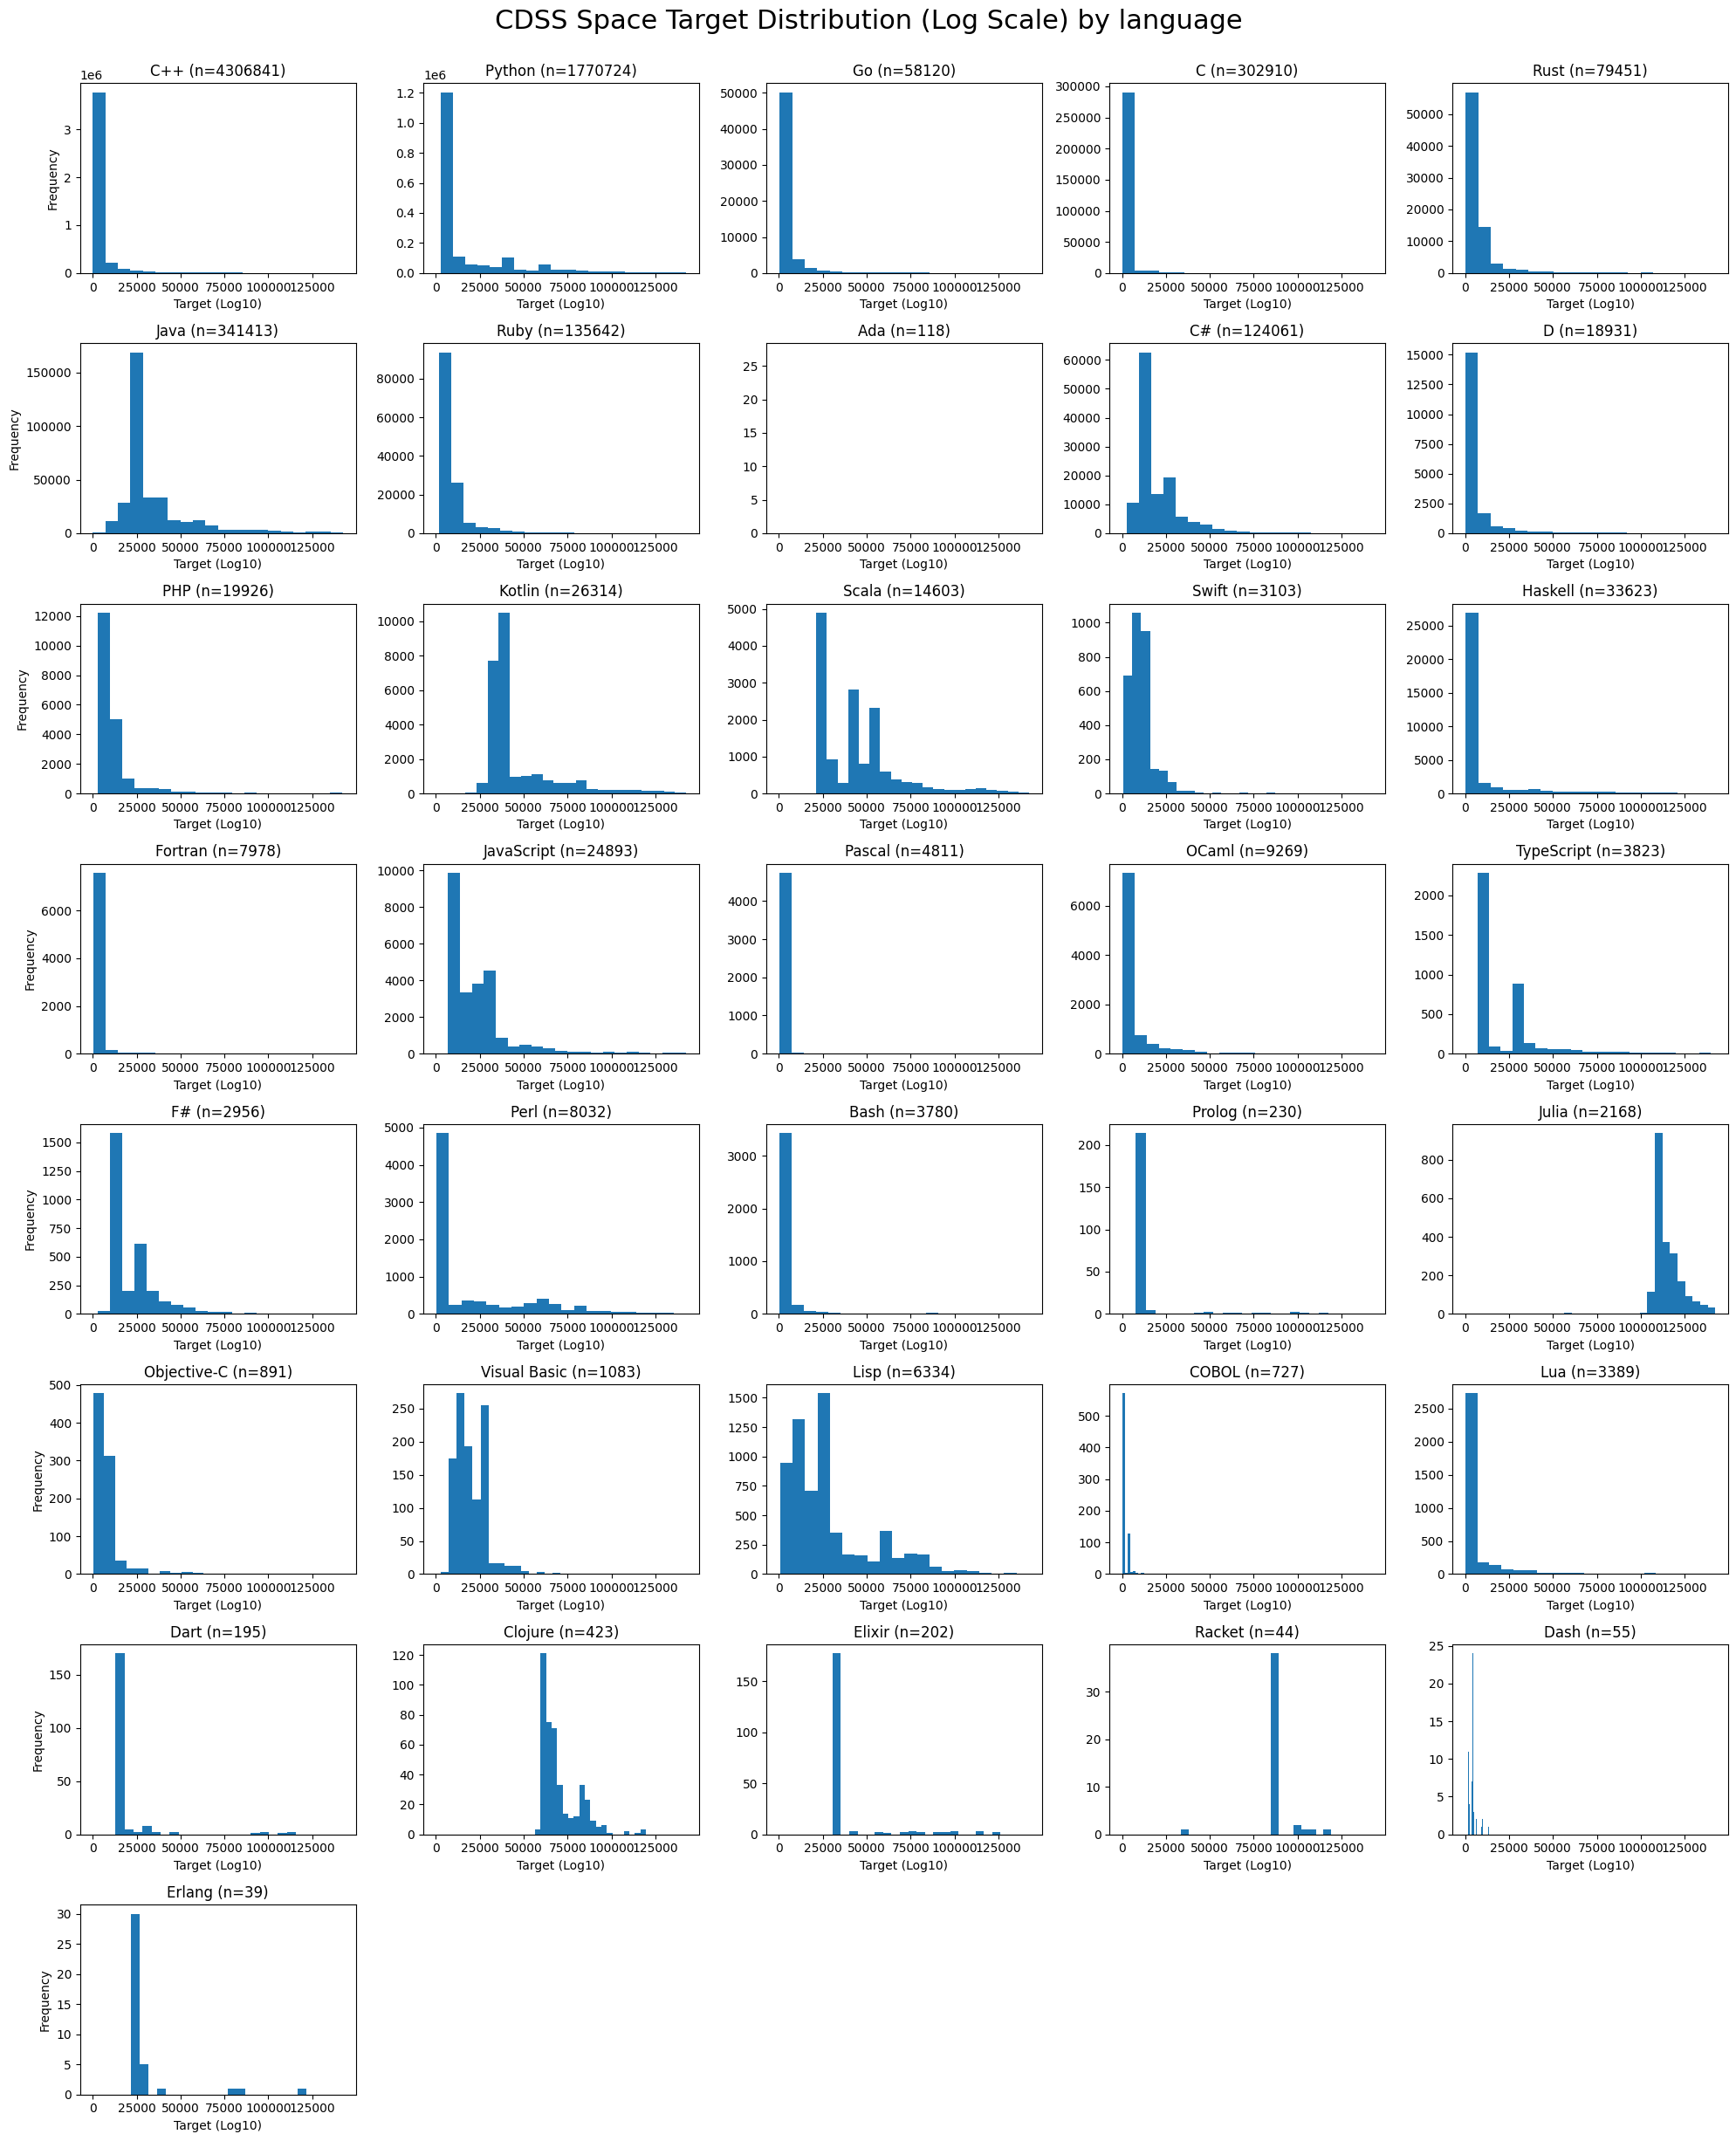

In [ ]:
plot_distributions_by_attribute_raw(filtered_cdss, 'language')

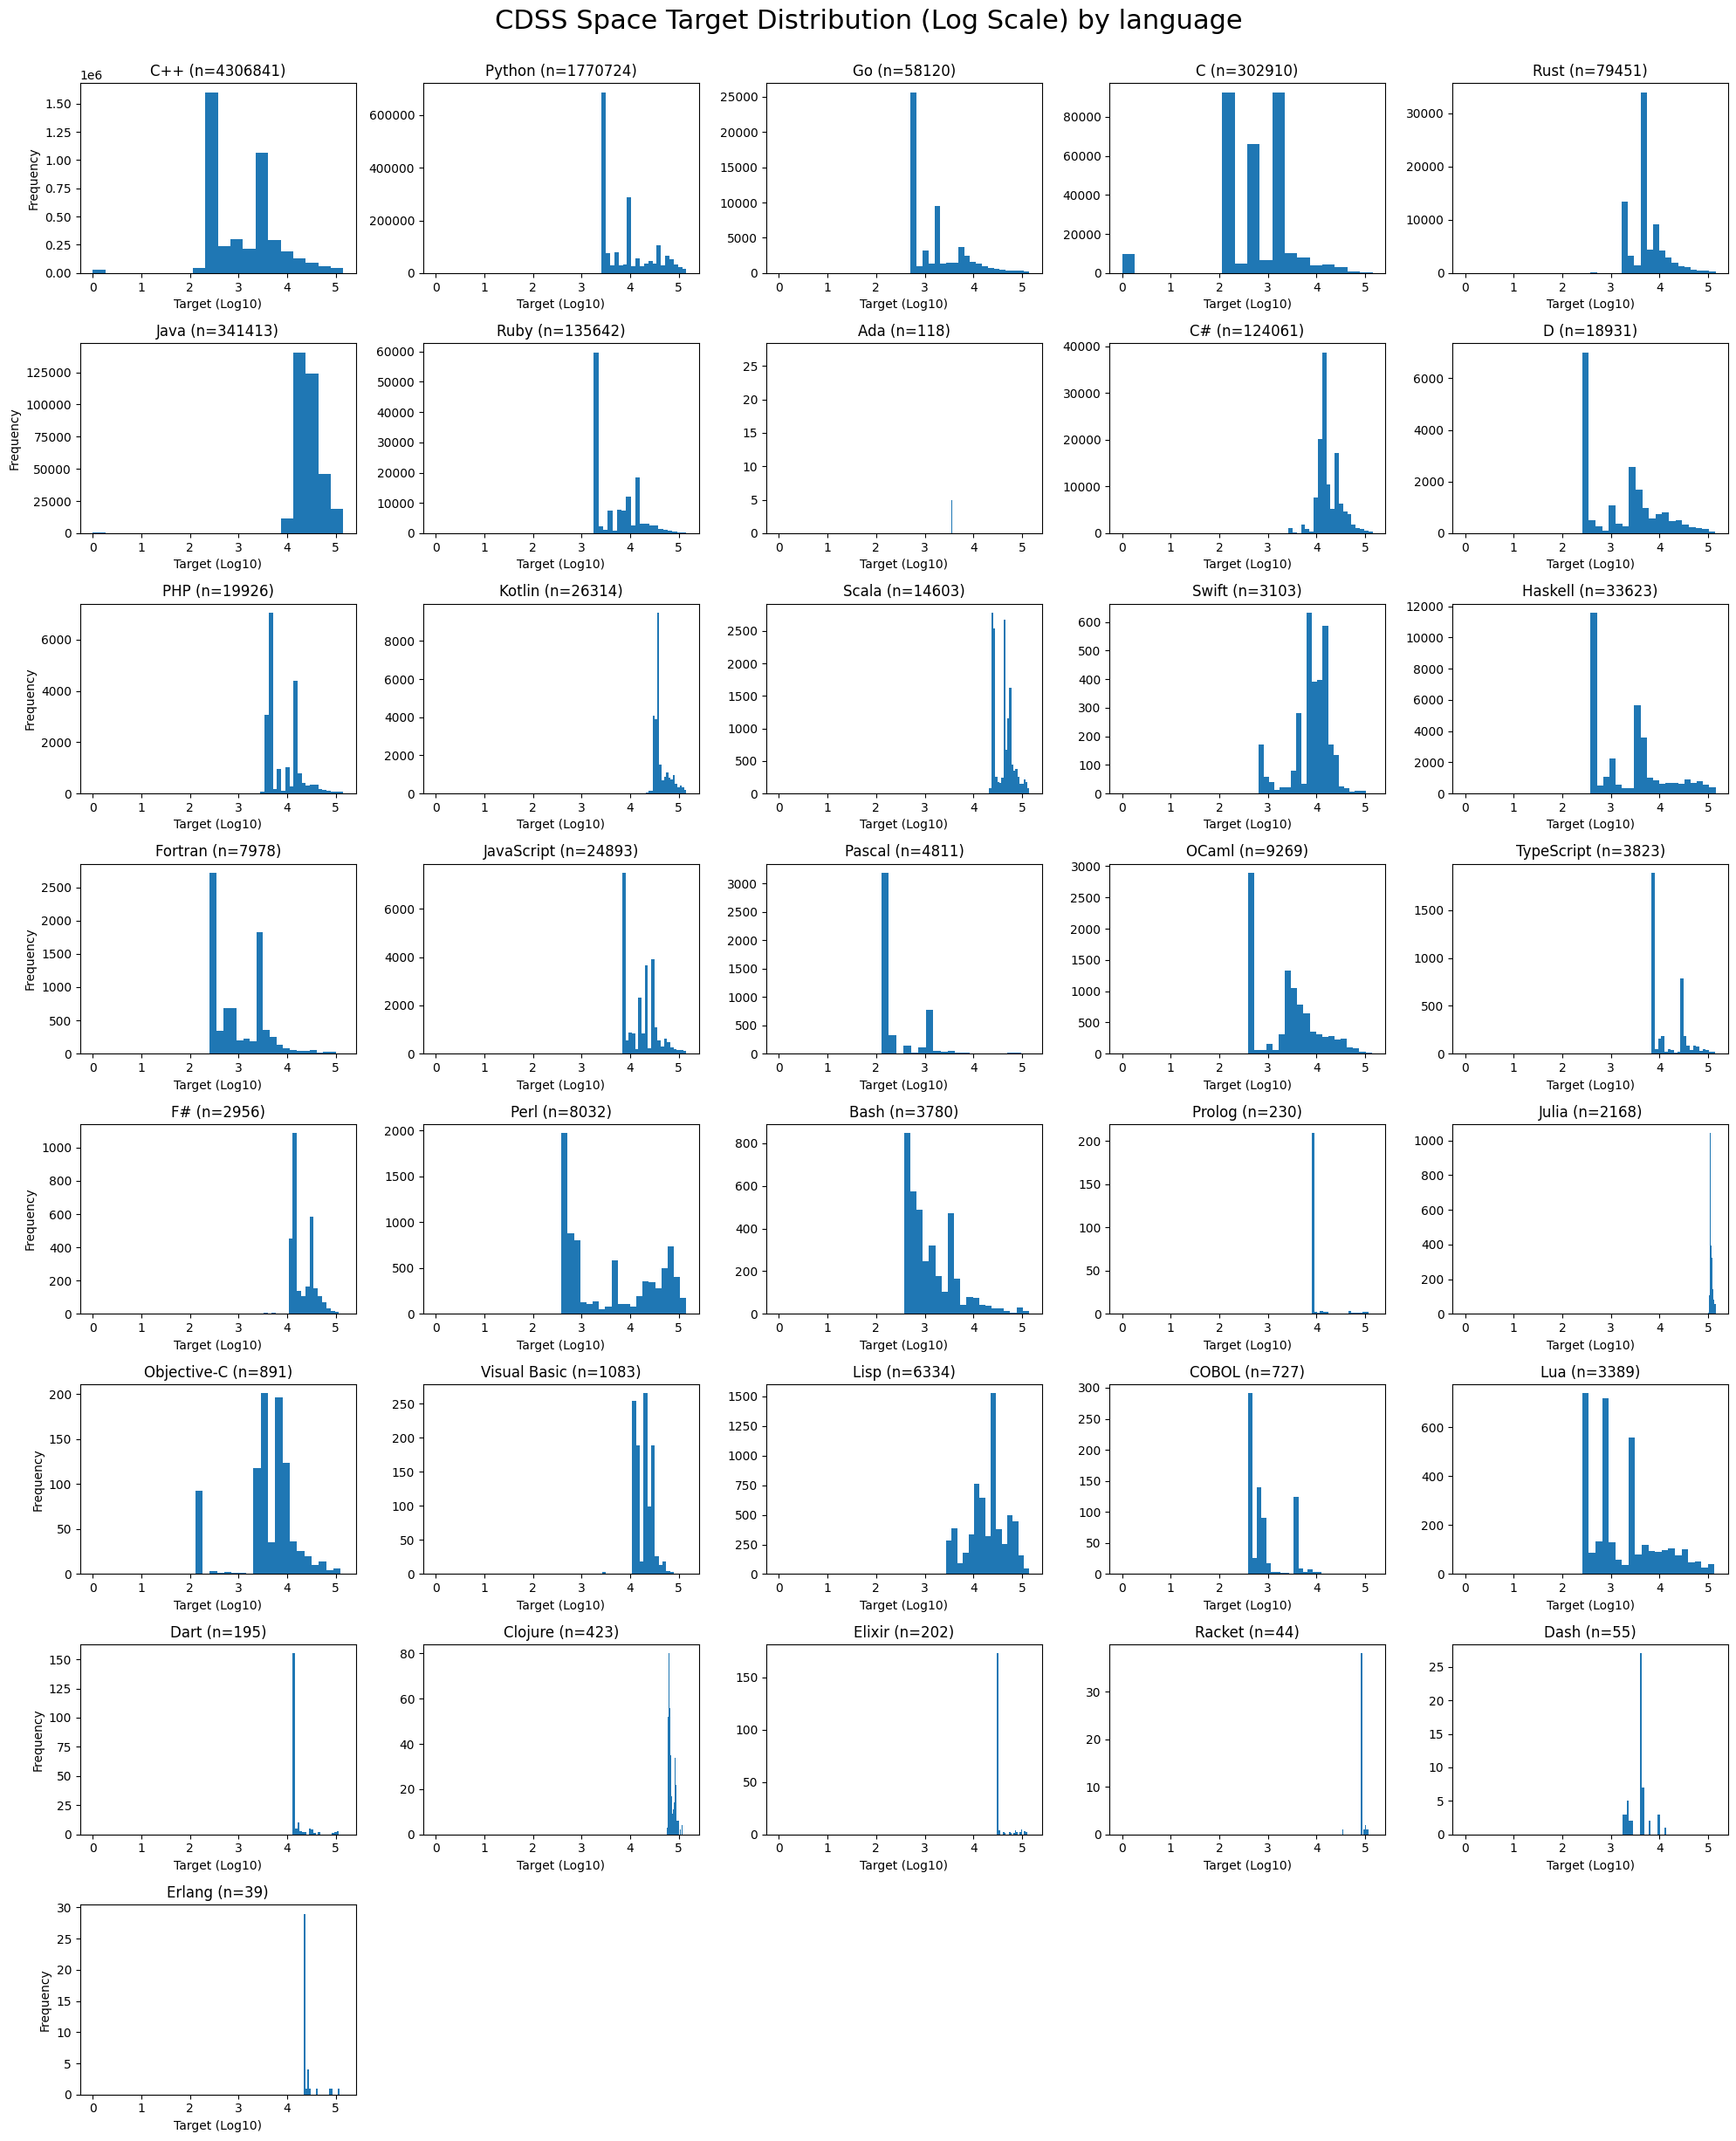

In [ ]:
plot_distributions_by_attribute(filtered_cdss, 'language')

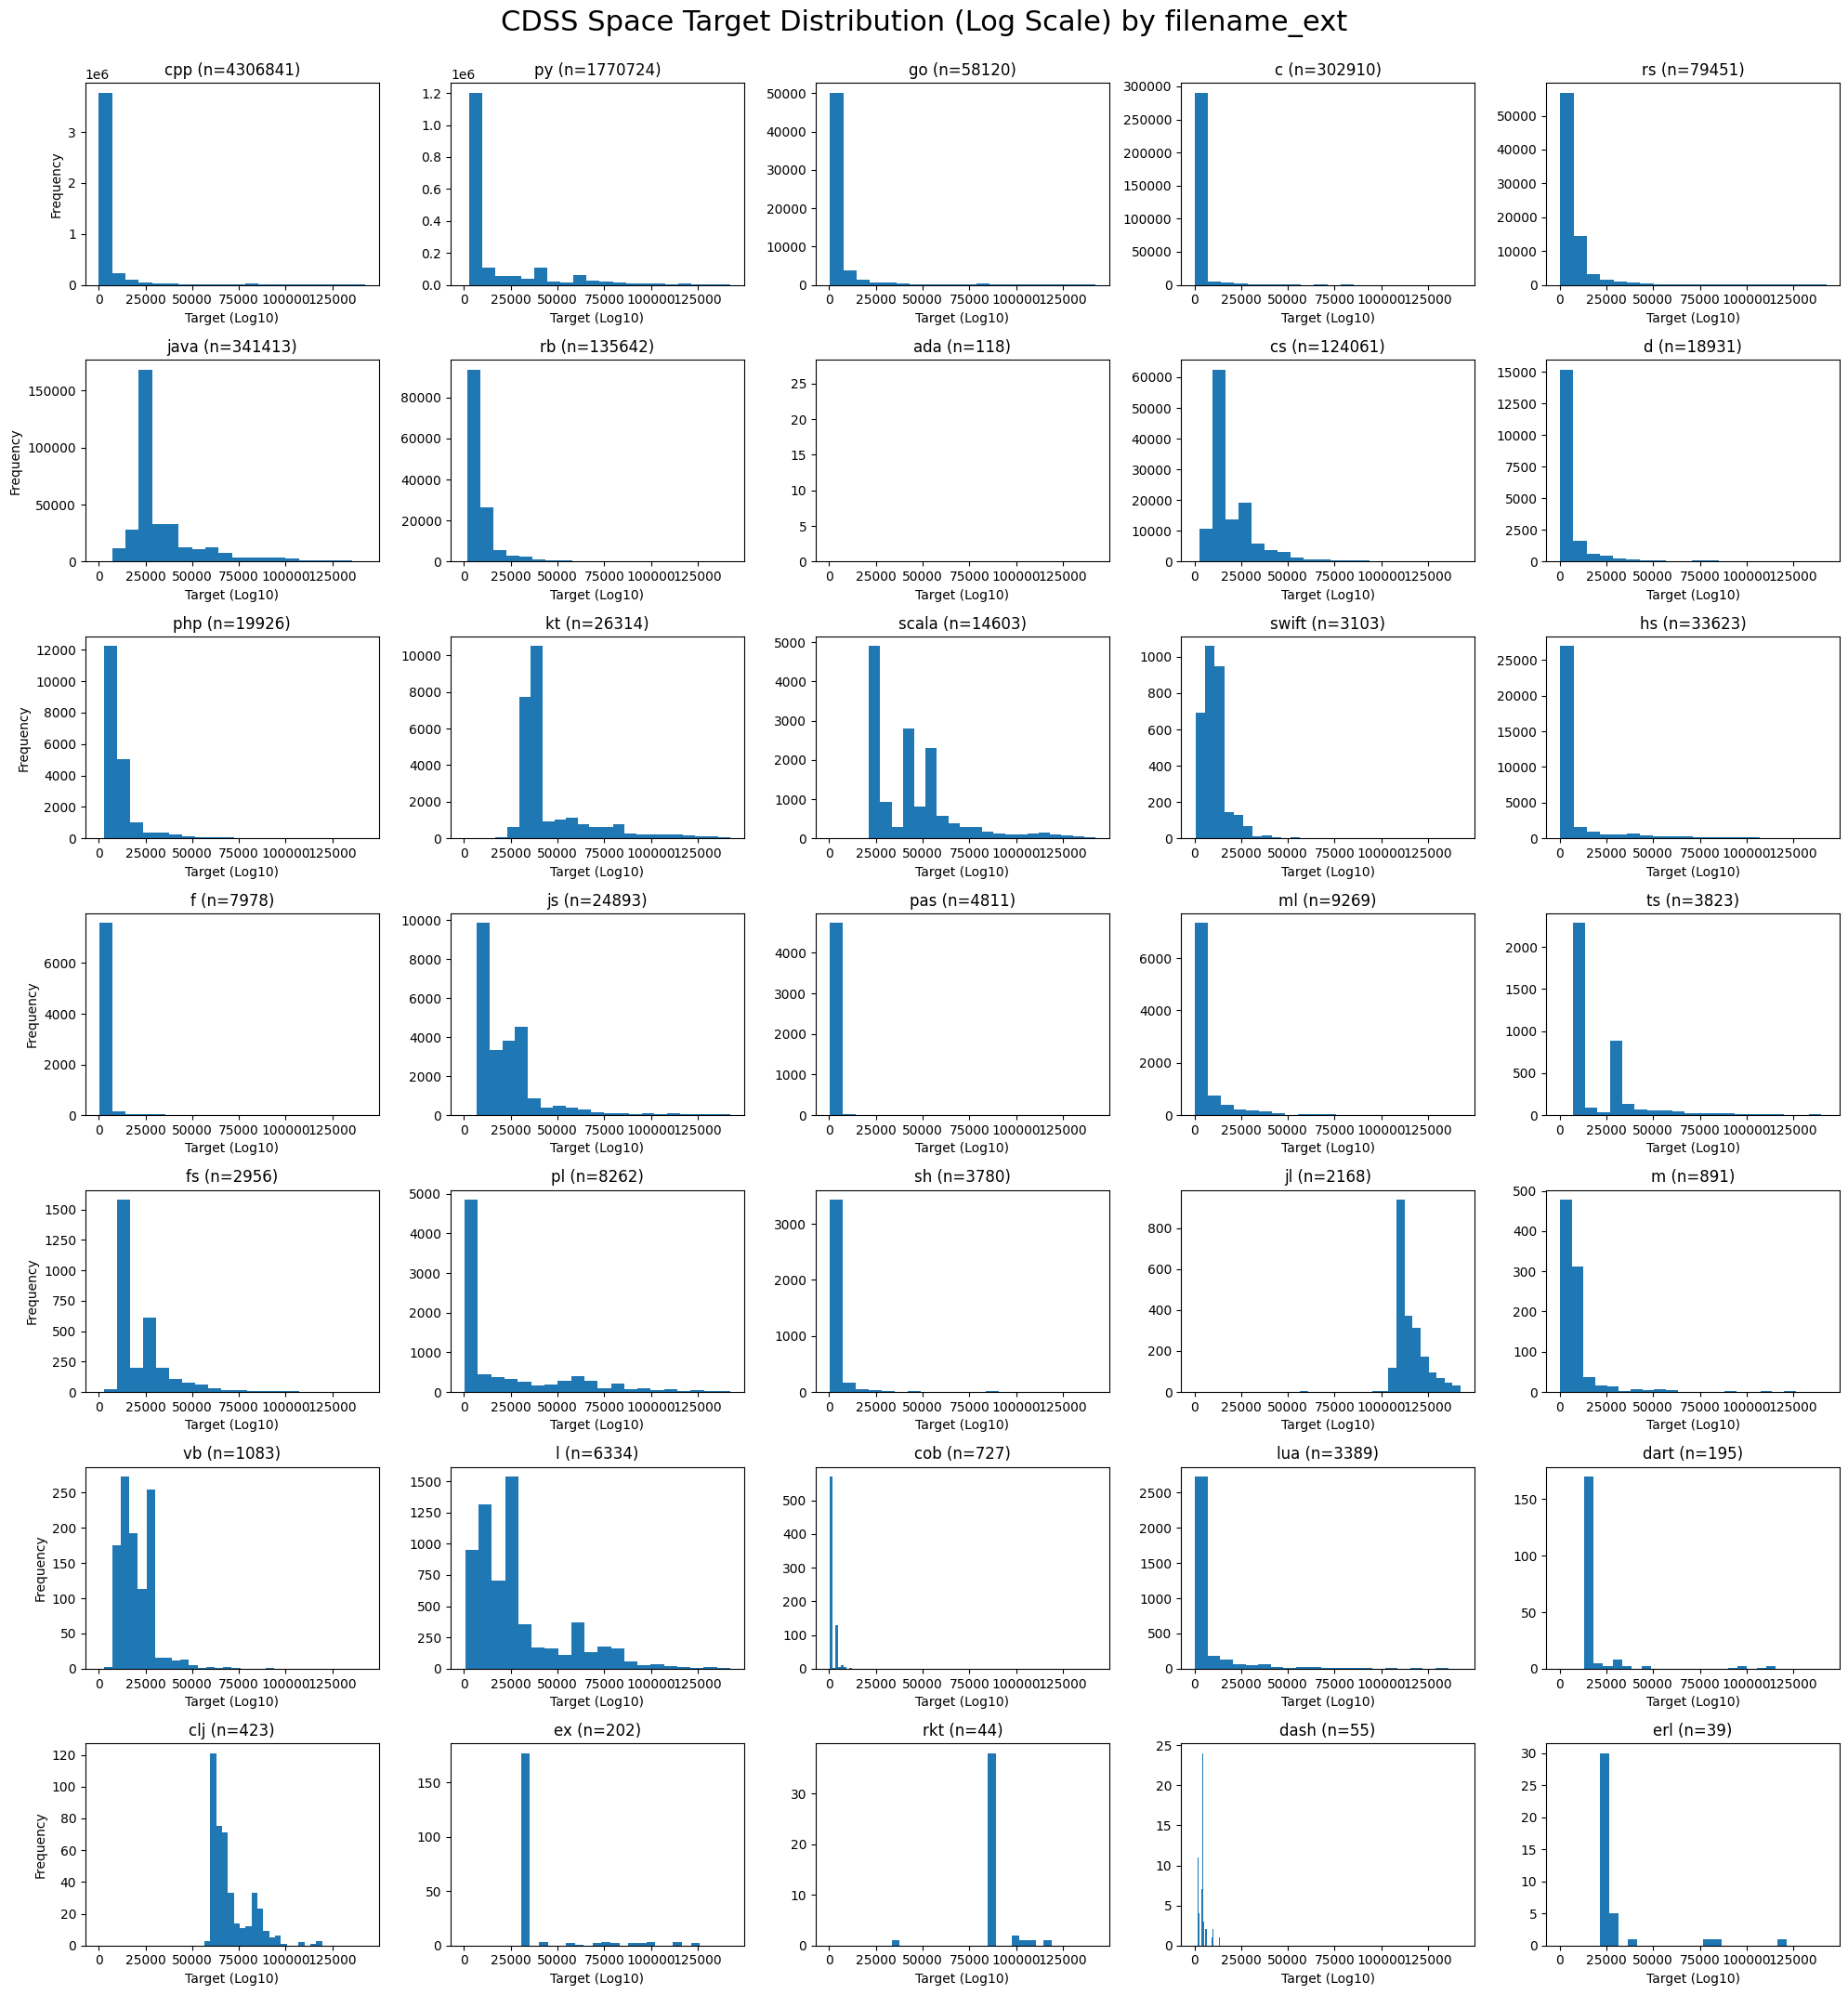

In [ ]:
plot_distributions_by_attribute_raw(filtered_cdss, 'filename_ext')

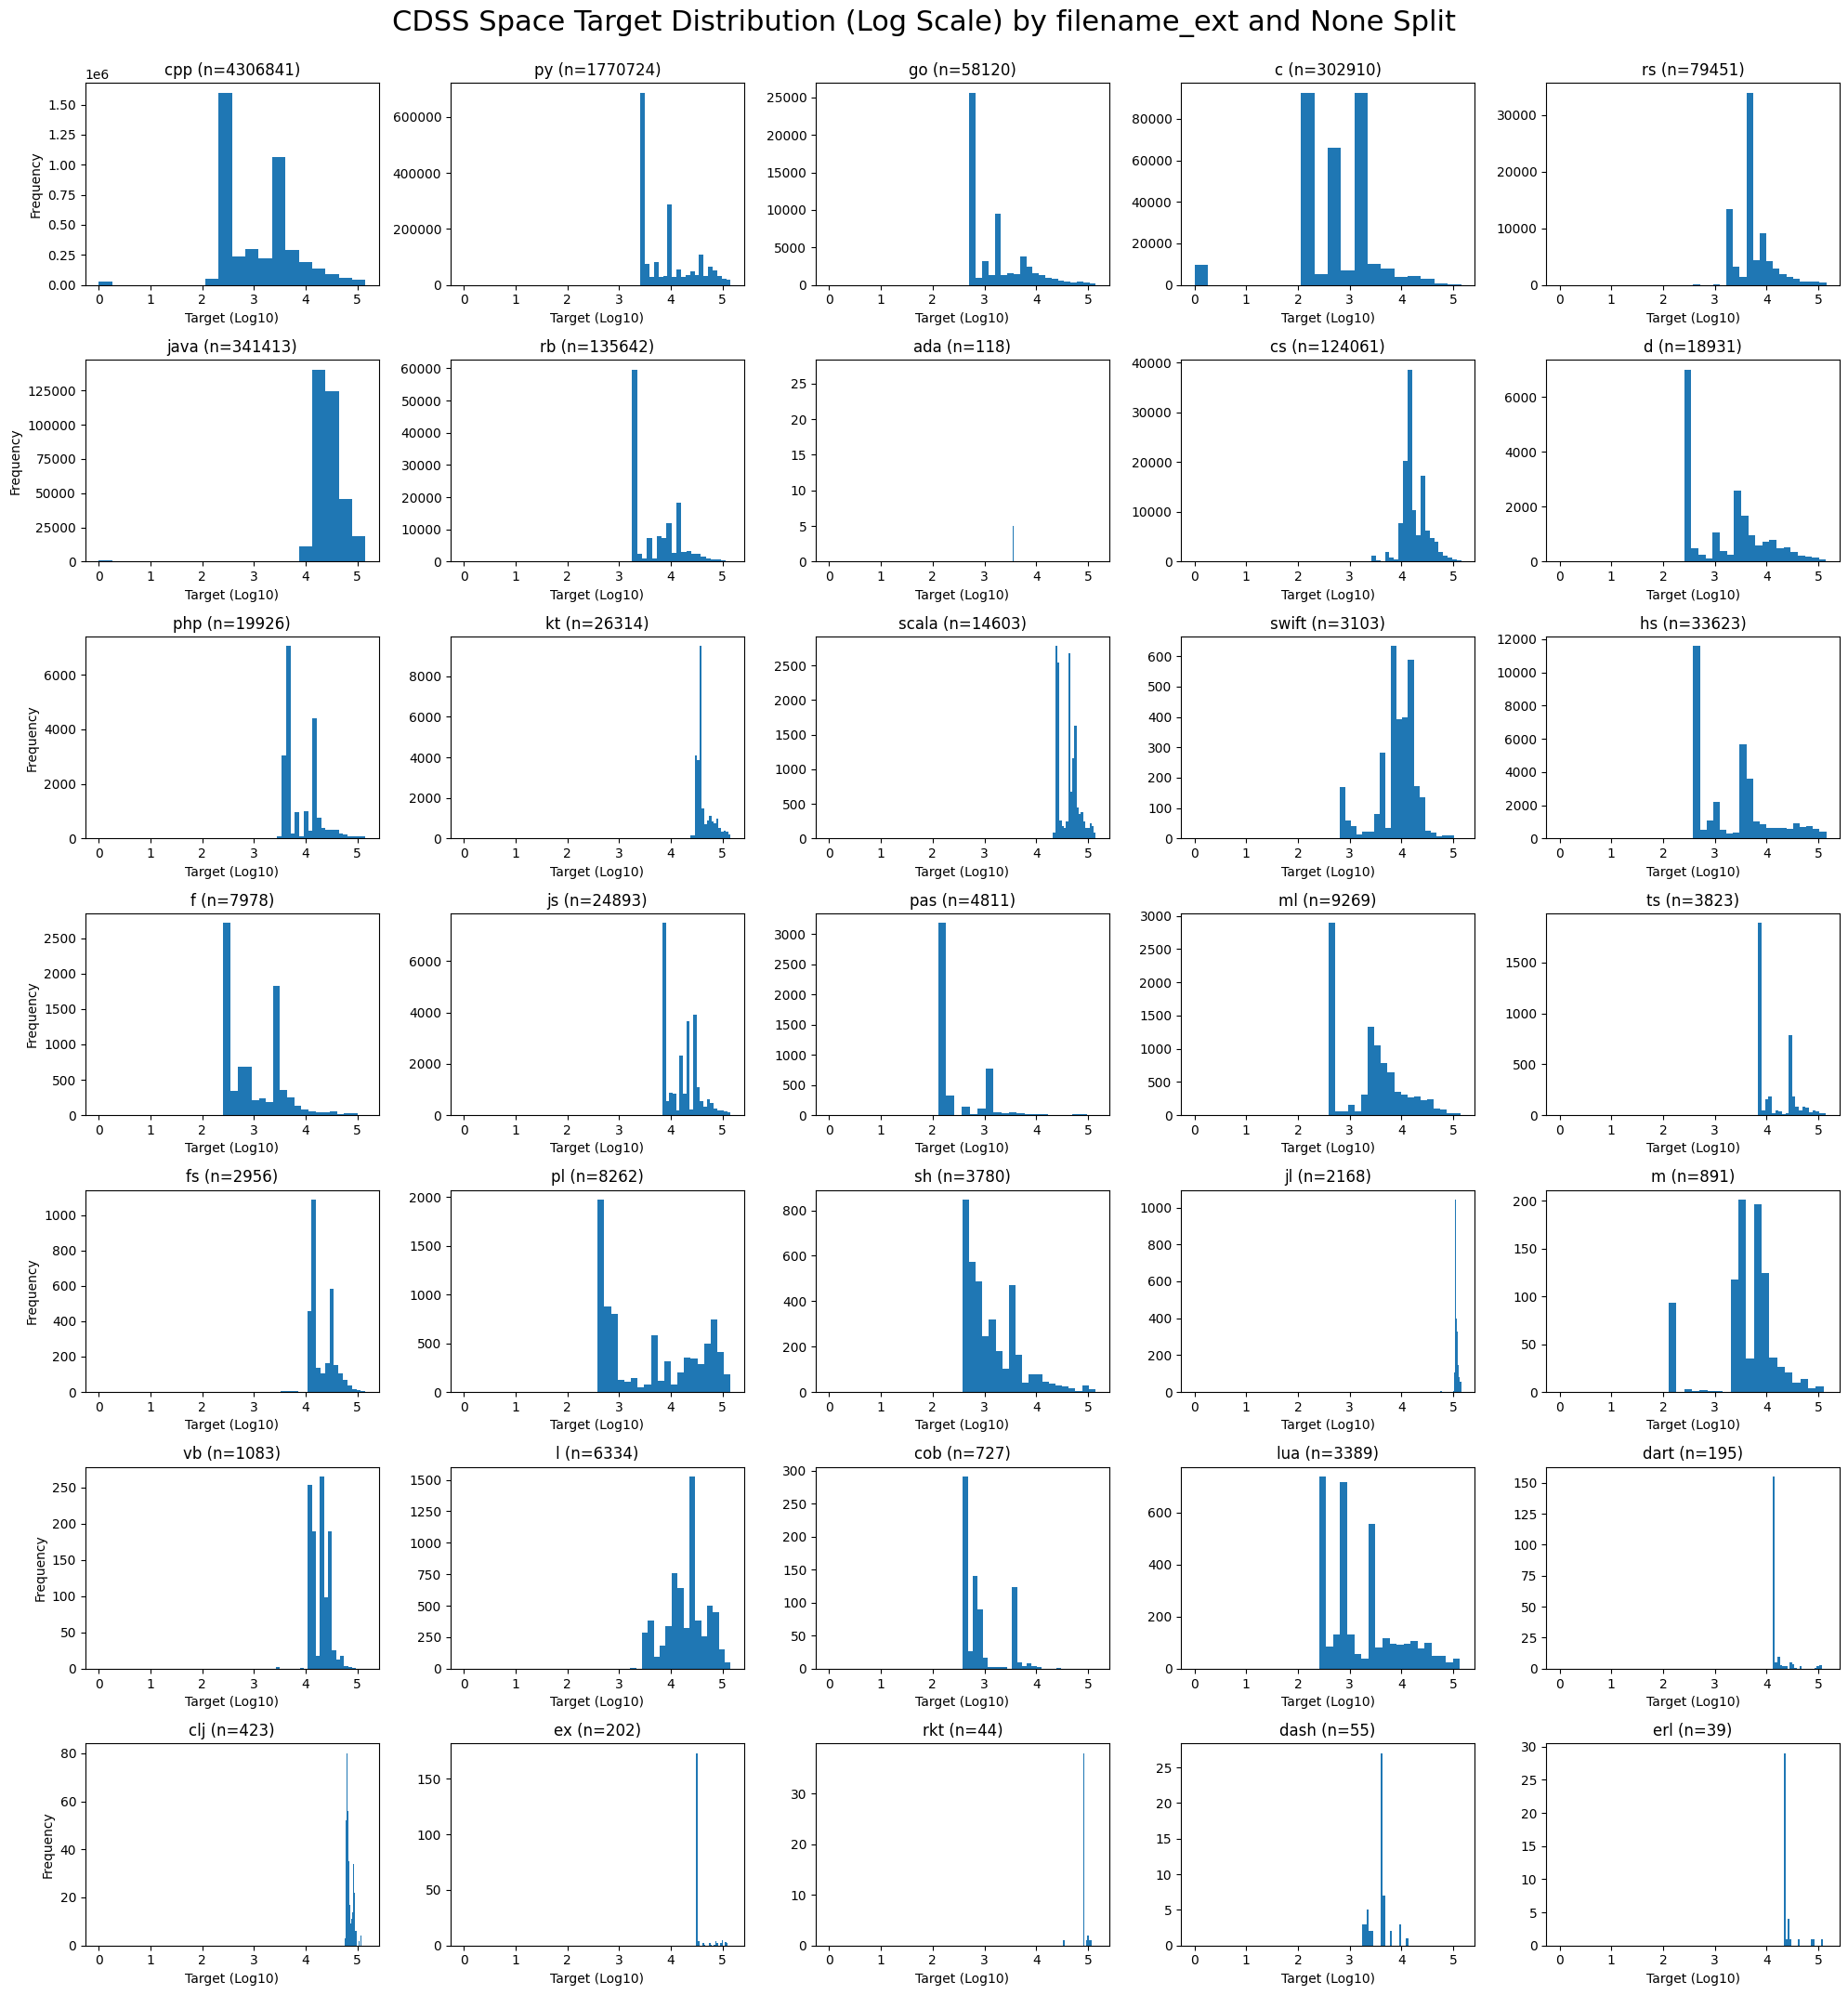

In [29]:
plot_distributions_by_attribute(filtered_cdss, 'filename_ext')

In [78]:
# Load in split df generated from preprocess_data.py script
split_df = pd.read_csv('split_df.csv')

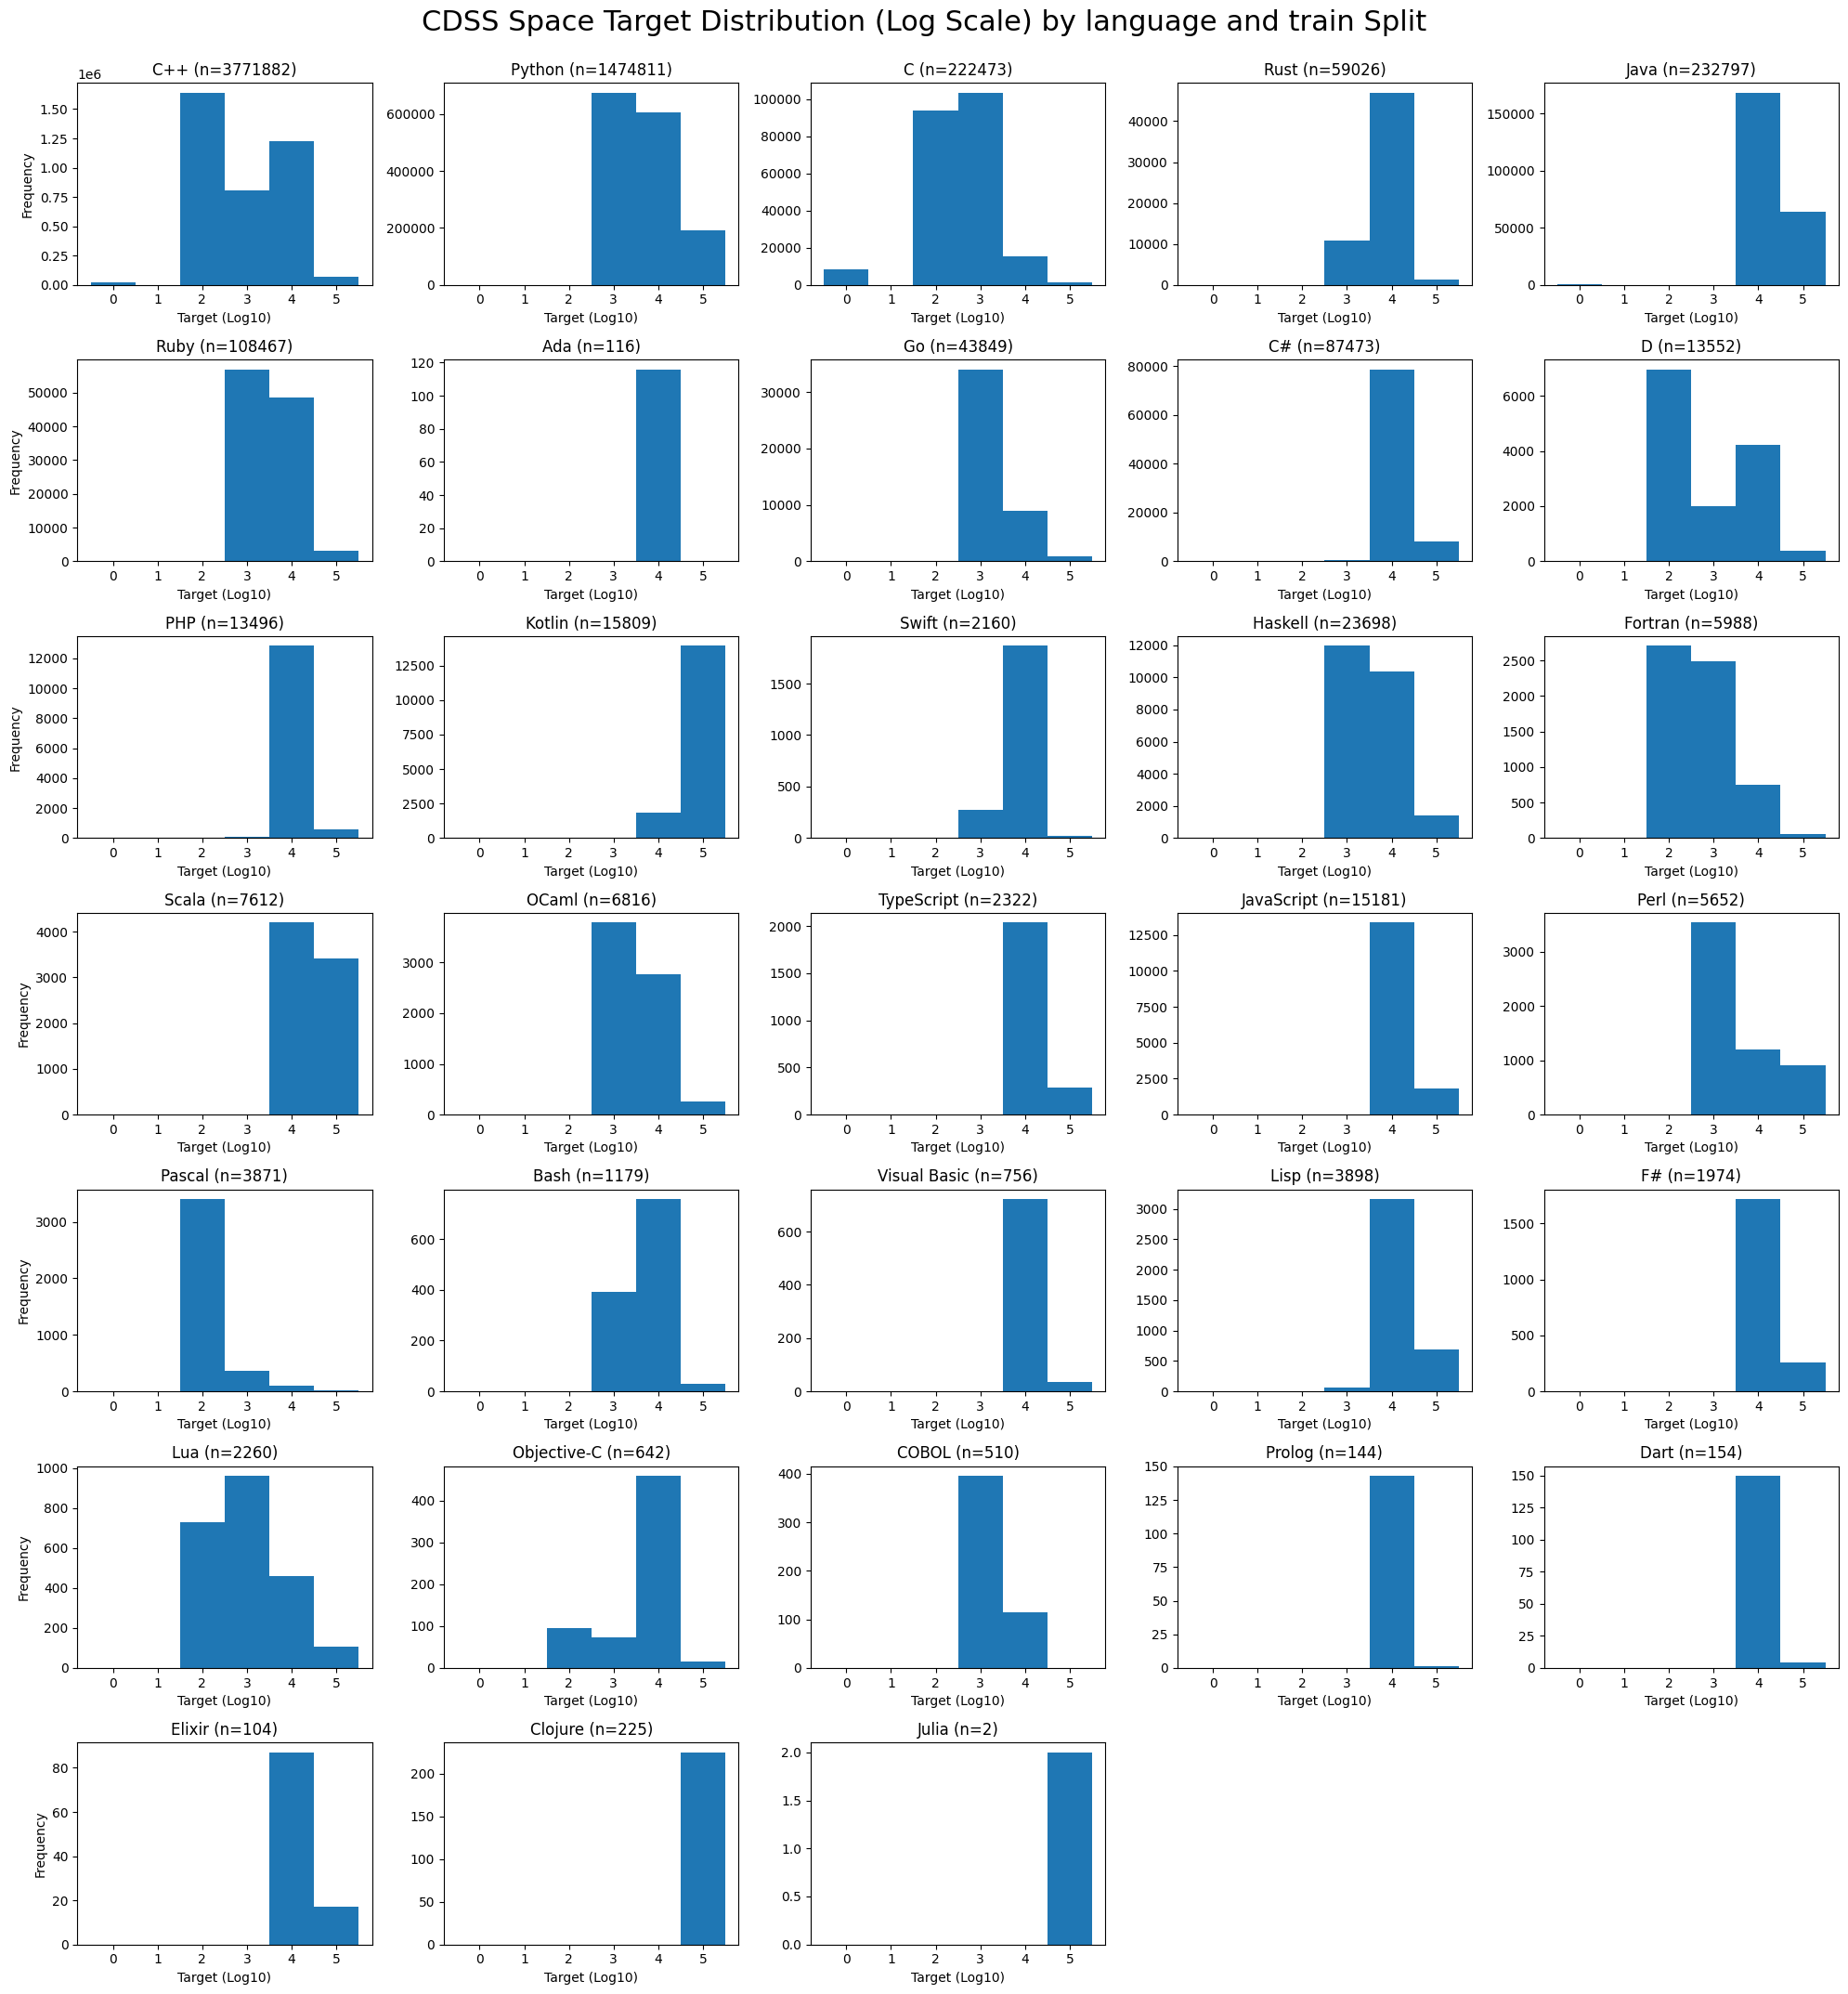

In [79]:
plot_distributions_by_attribute(split_df, "language", split="train")

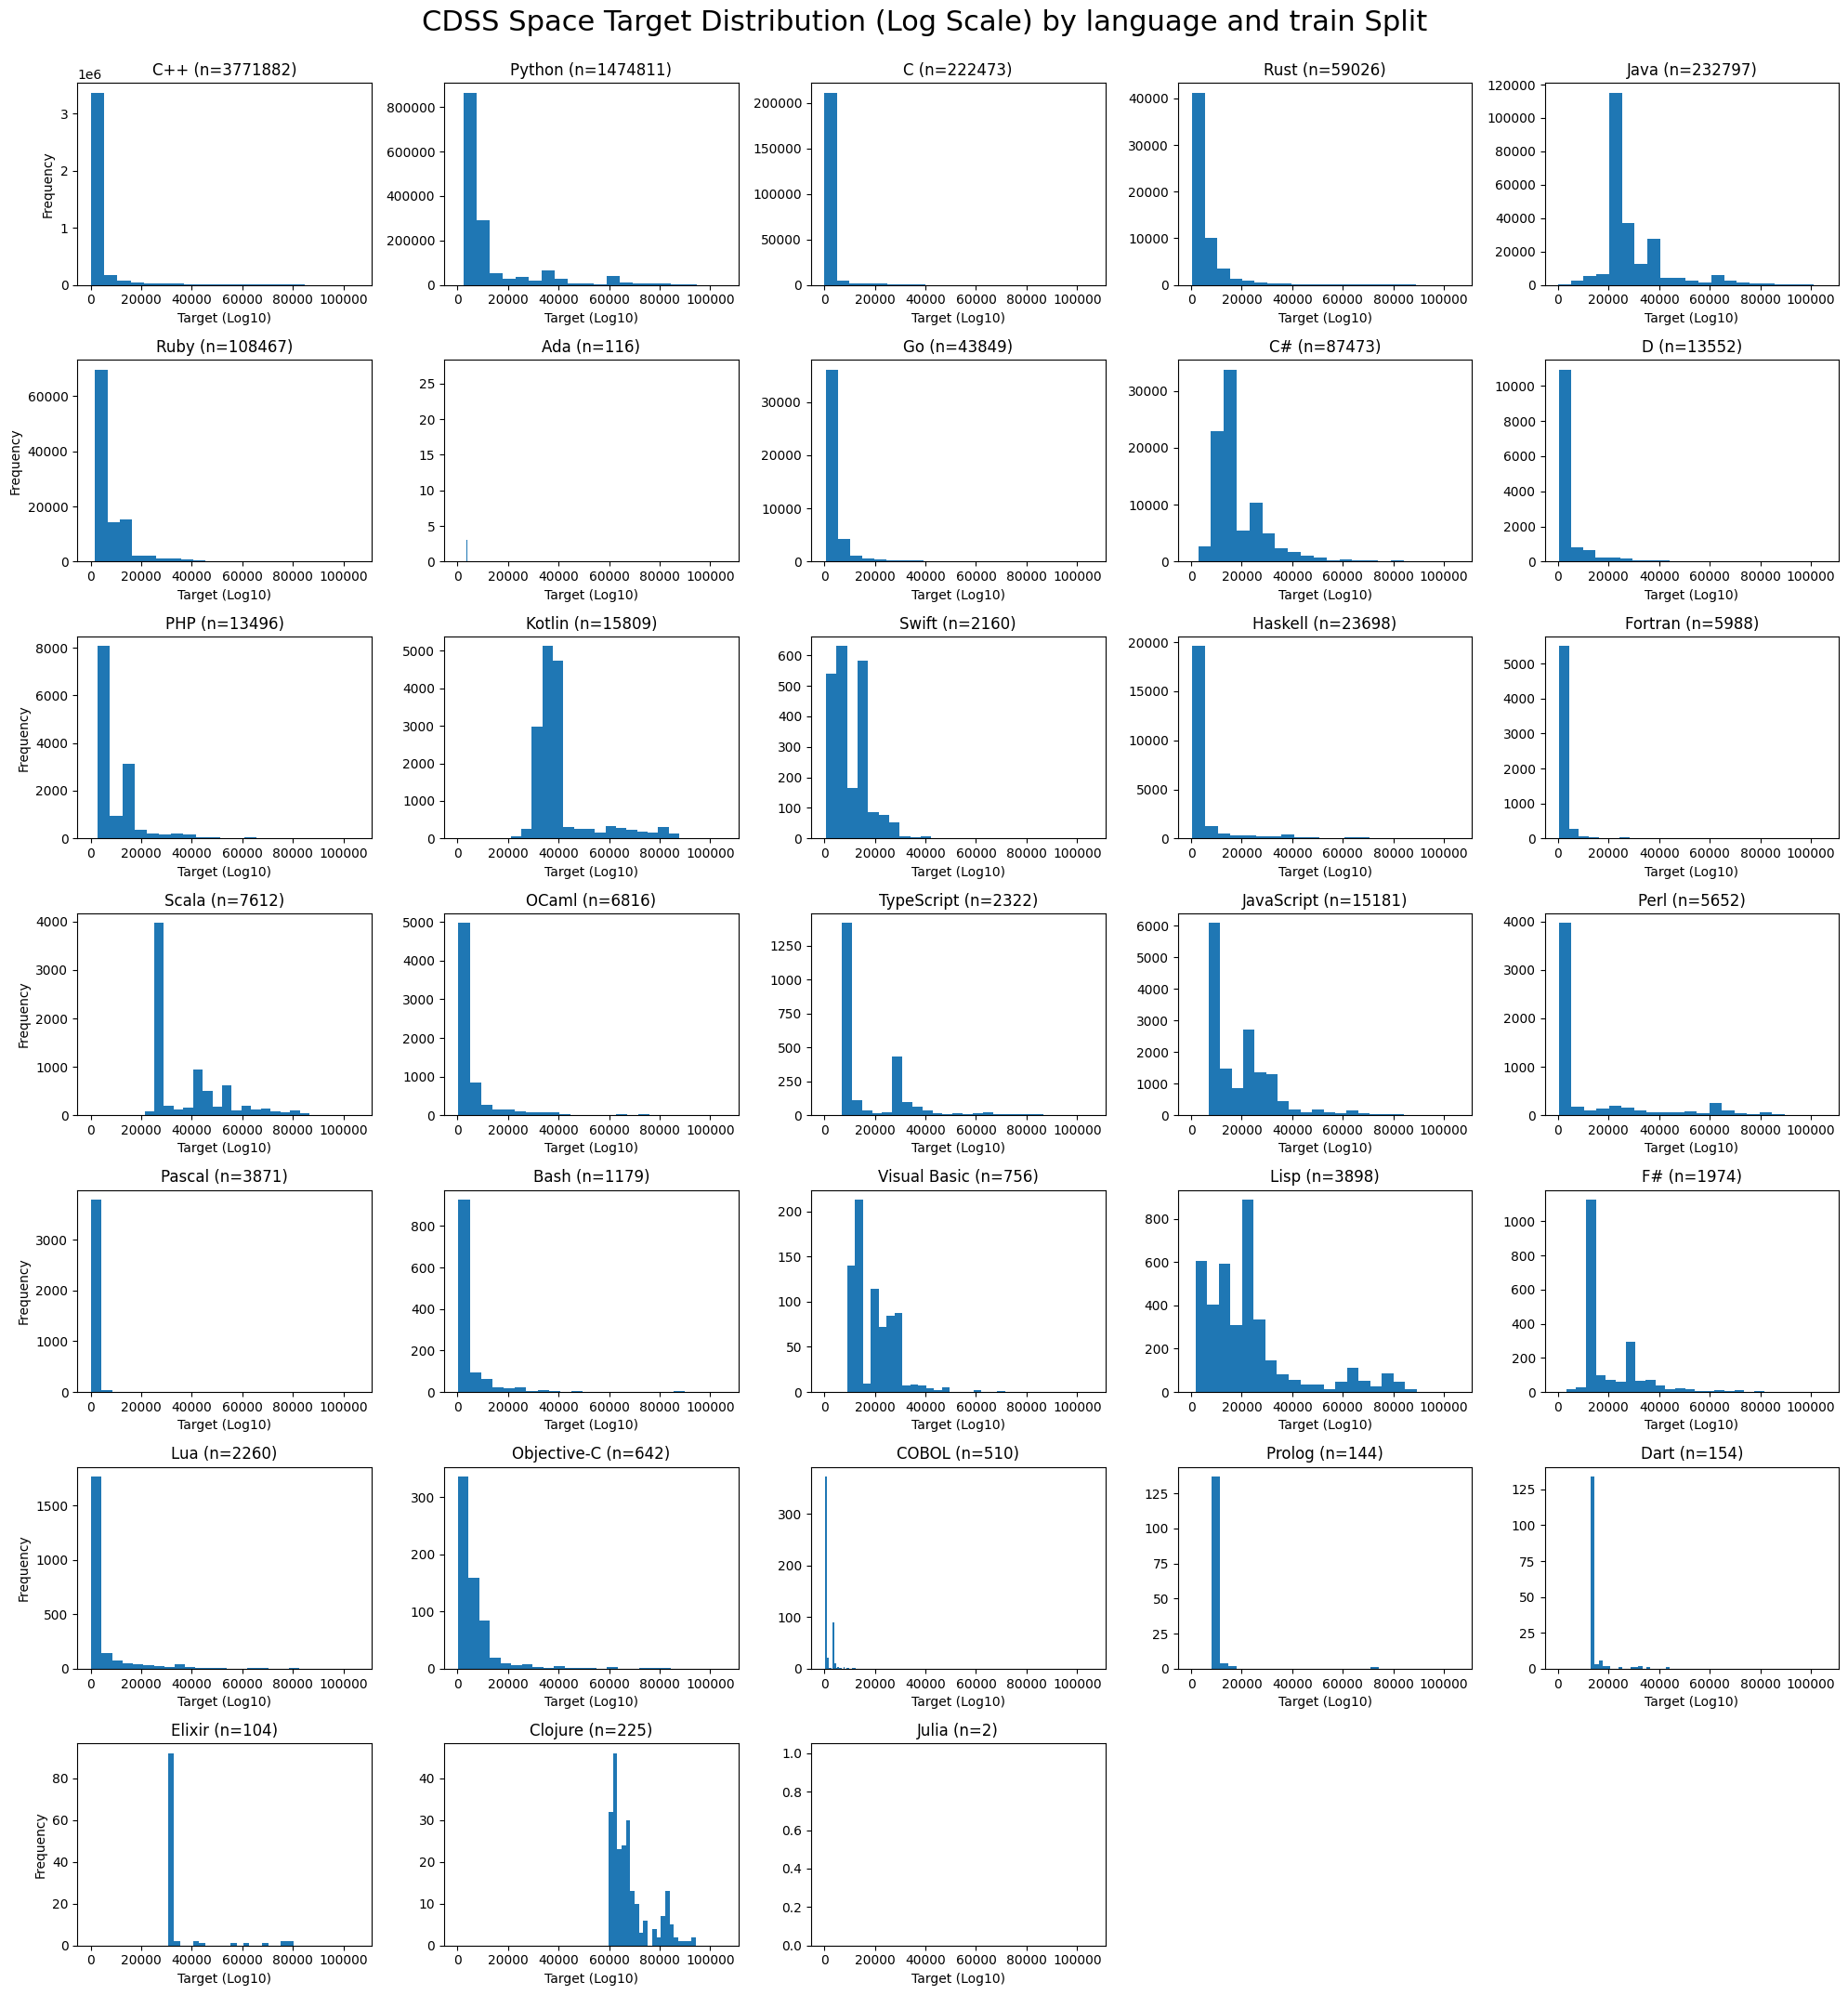

In [80]:
plot_distributions_by_attribute_raw(split_df, "language", split="train")

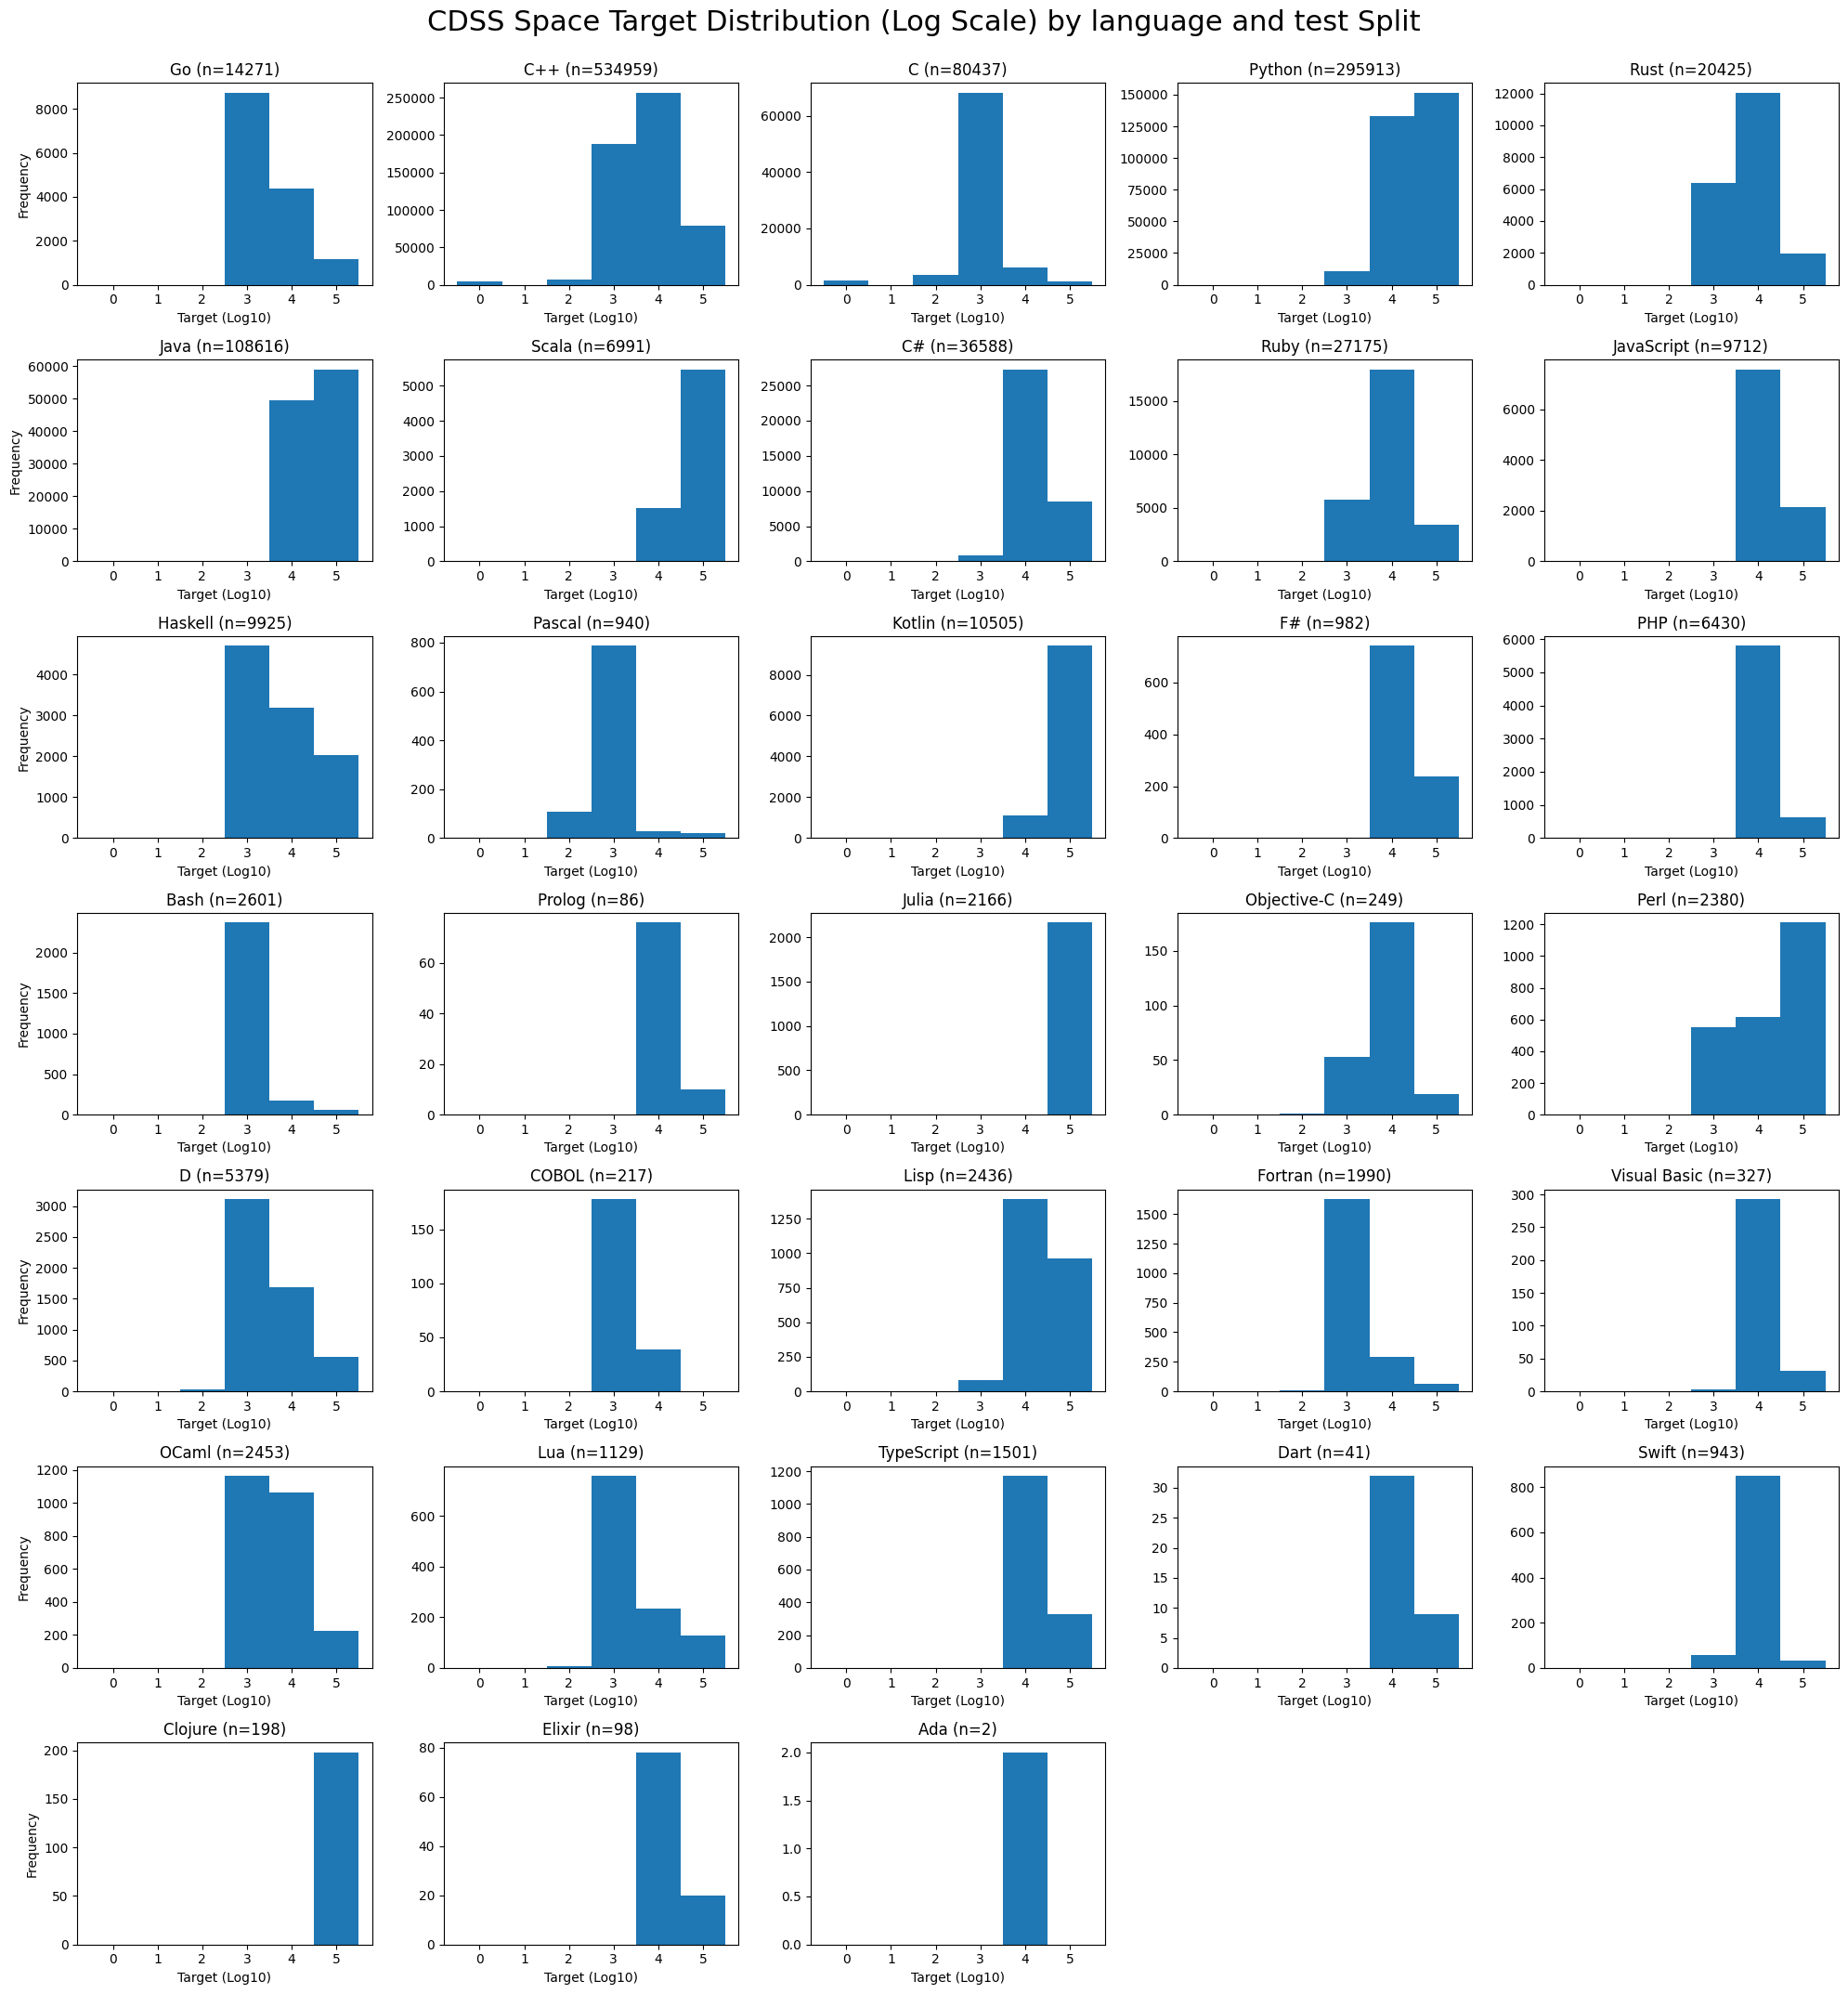

In [81]:
plot_distributions_by_attribute(split_df, "language", split="test")

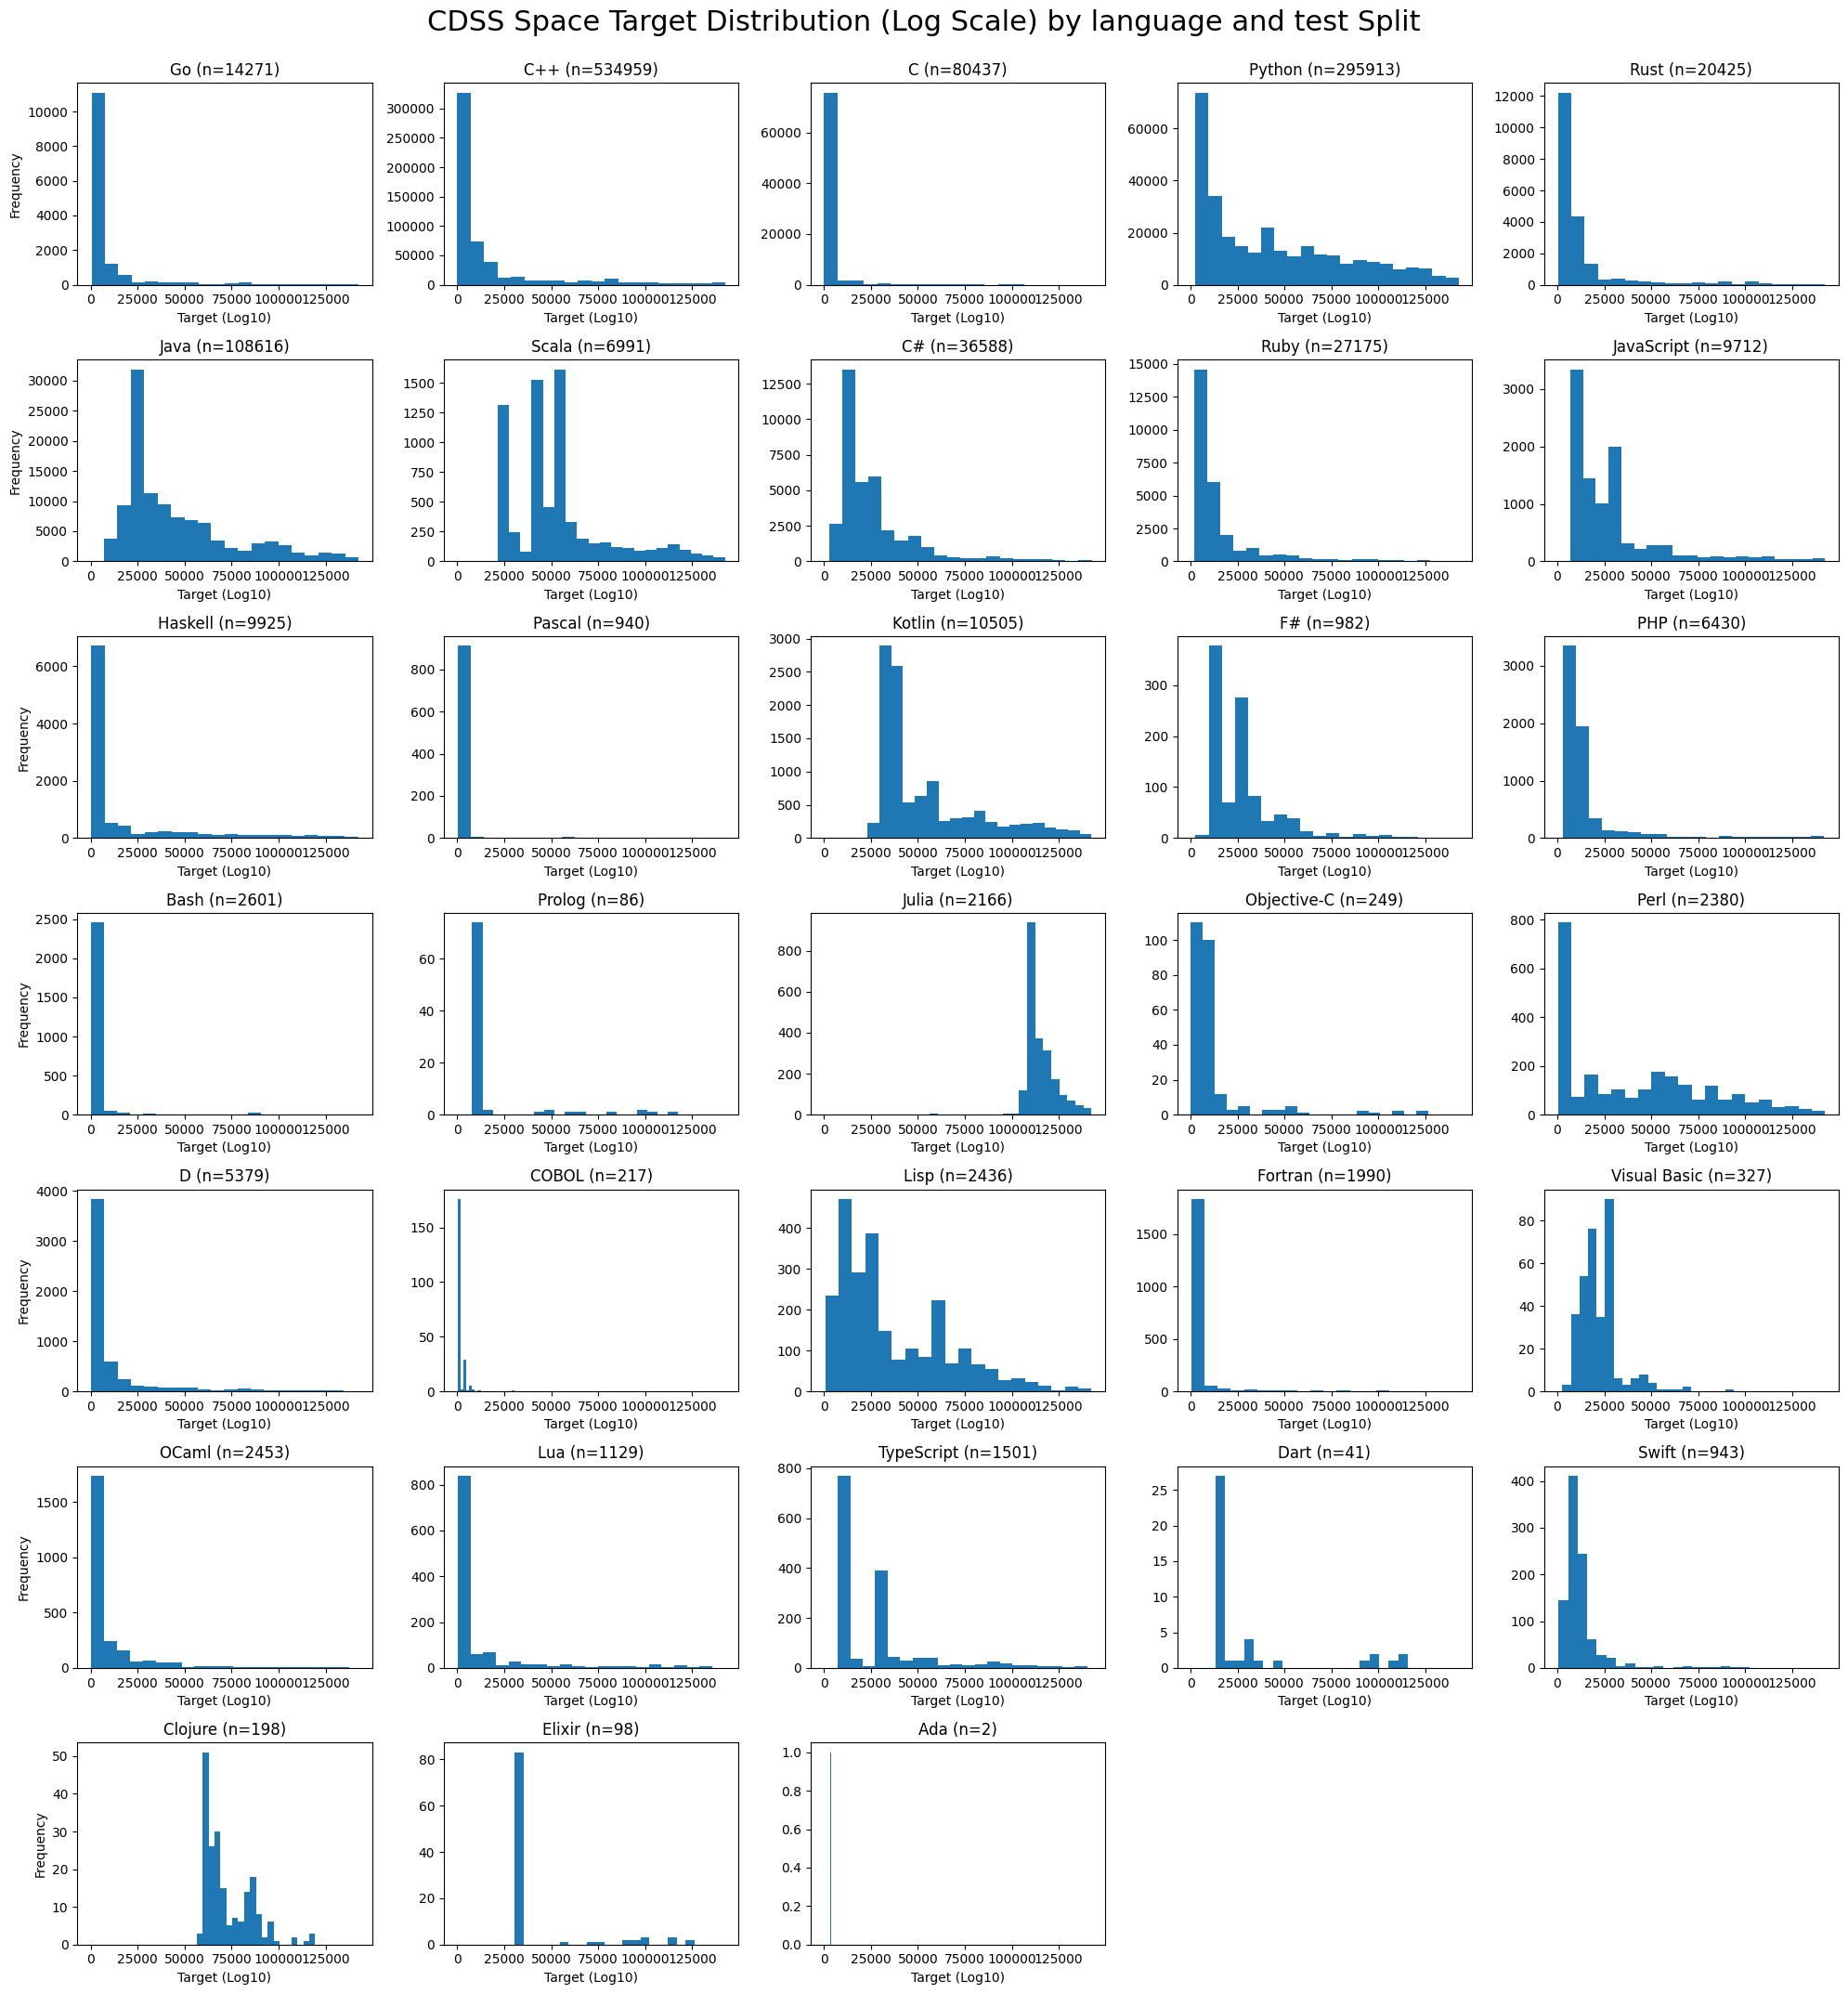

In [82]:
plot_distributions_by_attribute_raw(split_df, "language", split="test")

Evaluating the dataset after splitting it into a train and test set. The training set should retain a similar distribution of target values across different attributes, while the test set should have a uniform distribution of target values.

### Graph Regression Dataset Vizzes

In [ ]:
# Focusing on Code Regression dataset for now, but we can apply the same code to this dataset in the future!
# Load the dataset
ds = load_dataset("akhauriyash/GraphArch-Regression", split="train")